# Analisis exploratorio de los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_tibaitata = pd.read_pickle("./Datasets/TibaitataLimpio.pkl")

## Caracterizacion del dataset

In [4]:


df = df_tibaitata.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])

# --- Métricas generales del dataset ---
n_registros = len(df)
periodo_inicio = df['Fecha'].min()
periodo_fin = df['Fecha'].max()
dias_totales = (periodo_fin - periodo_inicio).days + 1
n_estaciones = df['CodigoEstacion'].nunique()
n_parametros = df['Parametro'].nunique()

# Frecuencia temporal: diferencia más común entre fechas consecutivas únicas
fechas_unicas = df['Fecha'].drop_duplicates().sort_values()
frecuencia_detectada = fechas_unicas.diff().mode()[0]

print("=== Resumen general del dataset ===")
print(f"Número de registros:       {n_registros}")
print(f"Periodo cubierto:          {periodo_inicio.date()} a {periodo_fin.date()} ({dias_totales} días)")
print(f"Frecuencia temporal:       {frecuencia_detectada}")
print(f"Número de estaciones:      {n_estaciones}")
print(f"Número de parámetros:      {n_parametros}")

# --- Tabla resumen por variable (Parametro) ---
resumen_variables = df.groupby('Parametro').agg(
    n_registros=('Valor', 'size'),
    n_validos=('Valor', 'count'),   # cuenta no-nulos
    n_nulos=('Valor', lambda x: x.isna().sum()),
    fecha_inicio=('Fecha', 'min'),
    fecha_fin=('Fecha', 'max'),
    n_estaciones=('CodigoEstacion', 'nunique'),
    unidad=('Unidad', lambda x: x.dropna().unique()[0] if x.dropna().nunique() > 0 else None)
).reset_index()

resumen_variables['dias_cubiertos'] = (
    (resumen_variables['fecha_fin'] - resumen_variables['fecha_inicio']).dt.days + 1
)
resumen_variables['pct_completitud'] = (
    resumen_variables['n_validos'] / resumen_variables['n_registros'] * 100
).round(2)

print("\n=== Tabla resumen de variables ===")
display(resumen_variables)

=== Resumen general del dataset ===
Número de registros:       14545
Periodo cubierto:          2005-02-02 a 2022-10-31 (6481 días)
Frecuencia temporal:       1 days 00:00:00
Número de estaciones:      2
Número de parámetros:      5

=== Tabla resumen de variables ===


,Parametro,n_registros,n_validos,n_nulos,fecha_inicio,fecha_fin,n_estaciones,unidad,dias_cubiertos,pct_completitud
0,Humedad relativa del aire a 2 metros media diaria,2909,2909,0,2005-02-02,2022-10-31,1,%,6481,100.0
1,Radiación solar global horaria VALIDADA,2909,2909,0,2005-02-02,2022-10-31,1,Wh/m^2,6481,100.0
2,Temperatura máxima diaria,2909,2909,0,2005-02-02,2022-10-31,1,degC,6481,100.0
3,Temperatura mínima diaria,2909,2909,0,2005-02-02,2022-10-31,1,degC,6481,100.0
4,Velocidad 10 minutal del viento media diaria,2909,2909,0,2005-02-02,2022-10-31,1,m/s,6481,100.0


## Estadistica descriptiva

=== Estadística descriptiva por variable ===


,Parametro,n_datos,media,mediana,desviacion_std,minimo,maximo,p25,p50,p75,coef_variacion_%
0,Humedad relativa del aire a 2 metros media diaria,2909,81.744,82.125,5.552,12.929,97.295,78.094,82.125,85.688,6.791
1,Radiación solar global horaria VALIDADA,2909,4156.220,4054.500,1241.474,233.000,7461.600,3240.000,4054.500,5033.100,29.870
2,Temperatura máxima diaria,2909,20.208,20.000,1.432,14.400,25.200,19.400,20.000,21.000,7.084
3,Temperatura mínima diaria,2909,7.420,7.800,2.710,-3.600,13.200,5.600,7.800,9.600,36.523
4,Velocidad 10 minutal del viento media diaria,2909,1.904,1.849,0.641,0.763,19.919,1.597,1.849,2.119,33.661


/tmp/ipykernel_9181/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


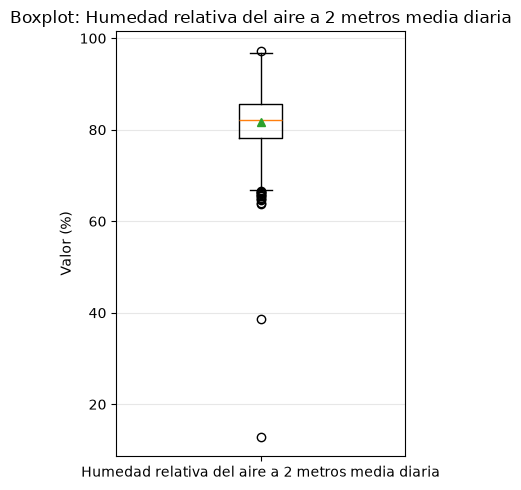

/tmp/ipykernel_9181/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


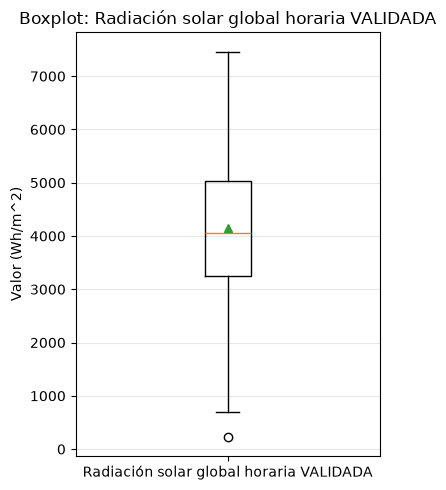

/tmp/ipykernel_9181/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


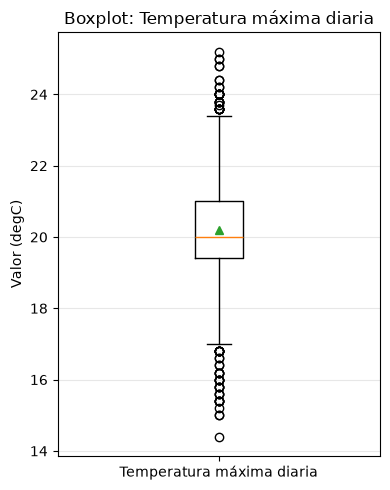

/tmp/ipykernel_9181/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


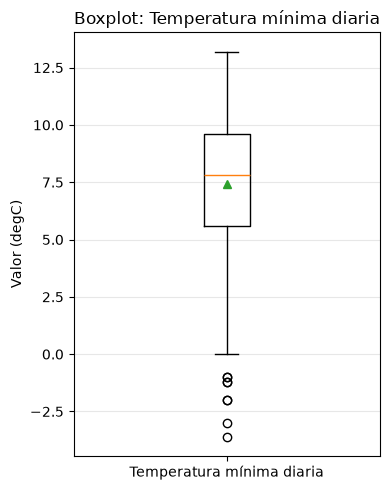

/tmp/ipykernel_9181/1744231240.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(datos, vert=True, showmeans=True)


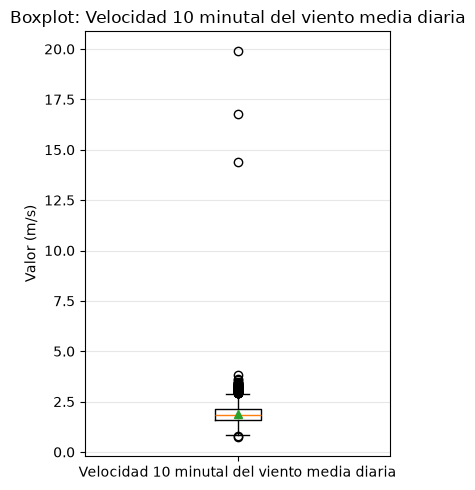

In [5]:
df = df_tibaitata.copy()

# --- Estadísticas descriptivas por variable (Parametro) ---
def coef_variacion(x):
    media = x.mean()
    return (x.std() / media * 100) if media != 0 else np.nan

estadisticas = df.groupby('Parametro')['Valor'].agg(
    n_datos='count',
    media='mean',
    mediana='median',
    desviacion_std='std',
    minimo='min',
    maximo='max',
    p25=lambda x: x.quantile(0.25),
    p50=lambda x: x.quantile(0.50),
    p75=lambda x: x.quantile(0.75),
).reset_index()

estadisticas['coef_variacion_%'] = df.groupby('Parametro')['Valor'].apply(coef_variacion).values
estadisticas = estadisticas.round(3)

print("=== Estadística descriptiva por variable ===")
display(estadisticas)

# --- Boxplot por cada variable (uno por figura, con su propia escala) ---
parametros = df['Parametro'].dropna().unique()

for param in parametros:
    datos = df.loc[df['Parametro'] == param, 'Valor'].dropna()
    unidad = df.loc[df['Parametro'] == param, 'Unidad'].dropna()
    unidad = unidad.iloc[0] if len(unidad) > 0 else ''

    plt.figure(figsize=(4, 5))
    plt.boxplot(datos, vert=True, showmeans=True)
    plt.title(f"Boxplot: {param}")
    plt.ylabel(f"Valor ({unidad})" if unidad else "Valor")
    plt.xticks([1], [param])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Parámetros disponibles en el dataset: ['Humedad relativa del aire a 2 metros media diaria', 'Radiación solar global horaria VALIDADA', 'Temperatura máxima diaria', 'Temperatura mínima diaria', 'Velocidad 10 minutal del viento media diaria']

Mapeo detectado:
  temp_min: None
  precipitacion: None
  humedad: Humedad relativa del aire a 2 metros media diaria


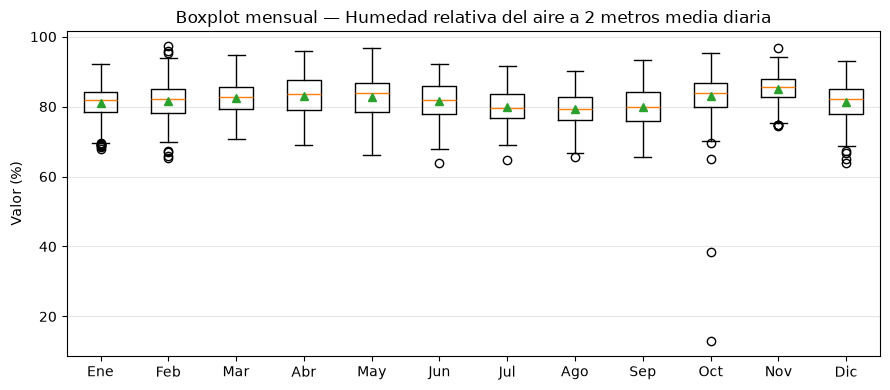

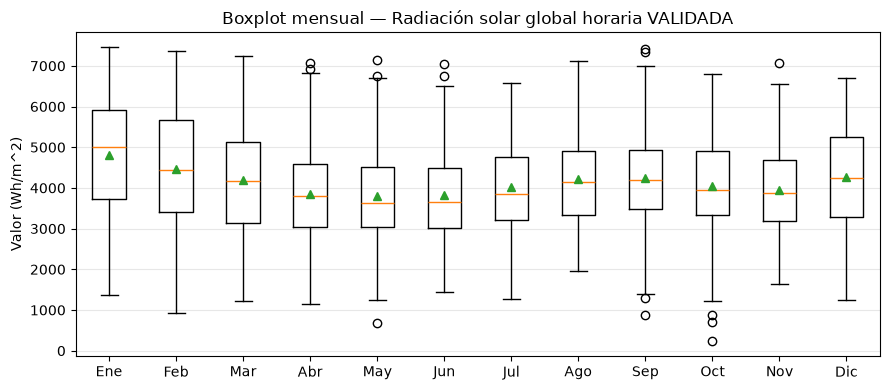

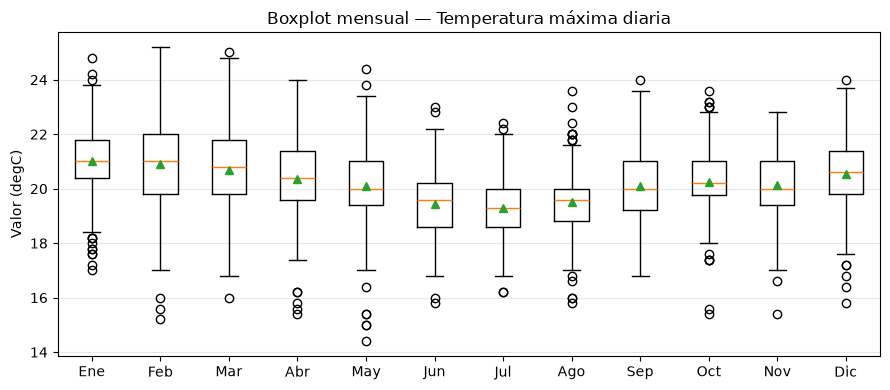

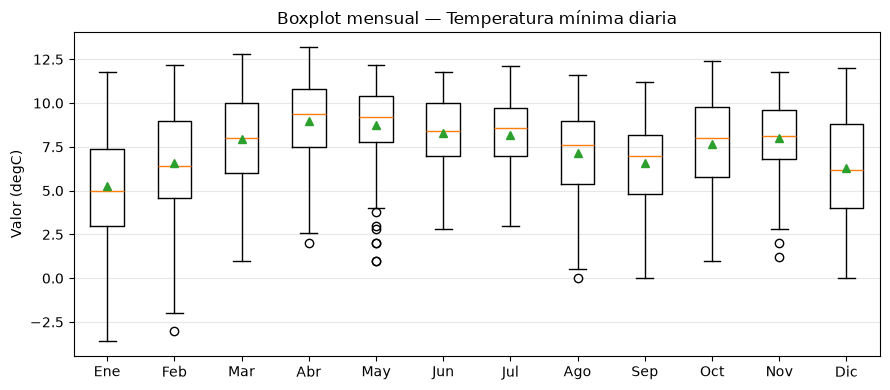

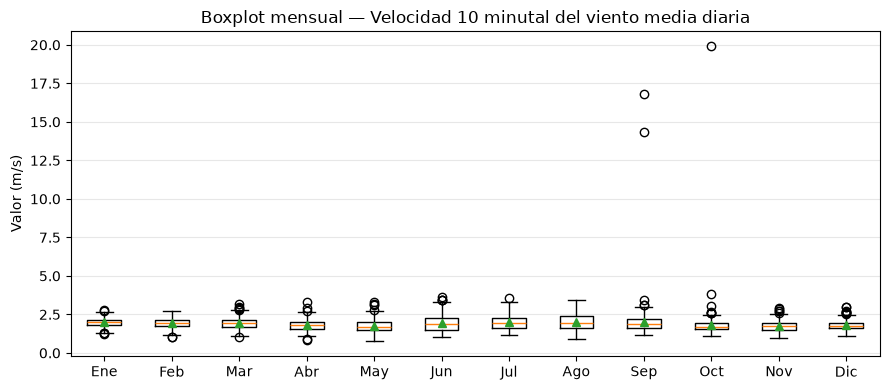

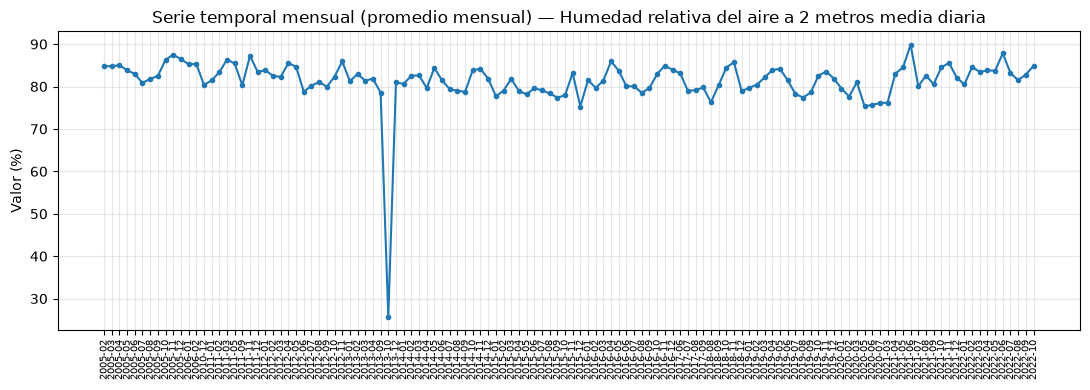

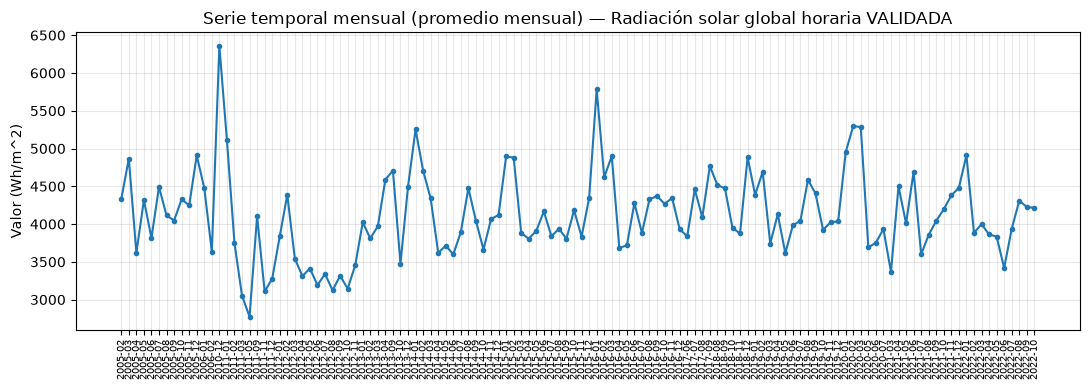

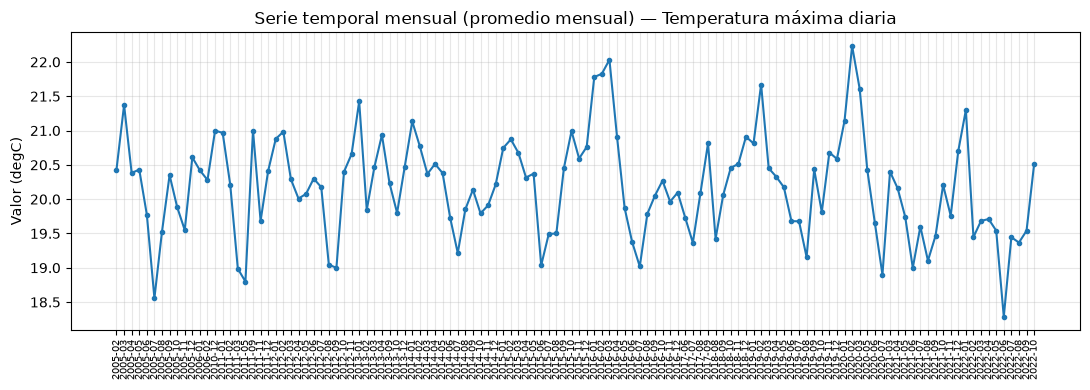

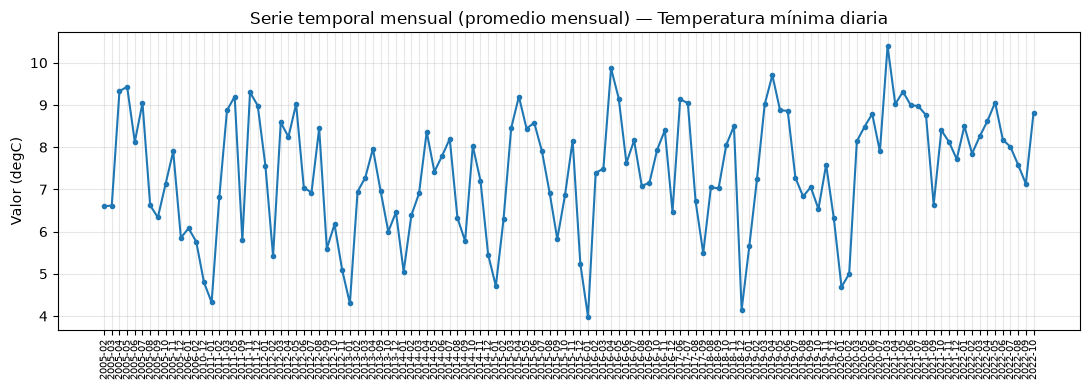

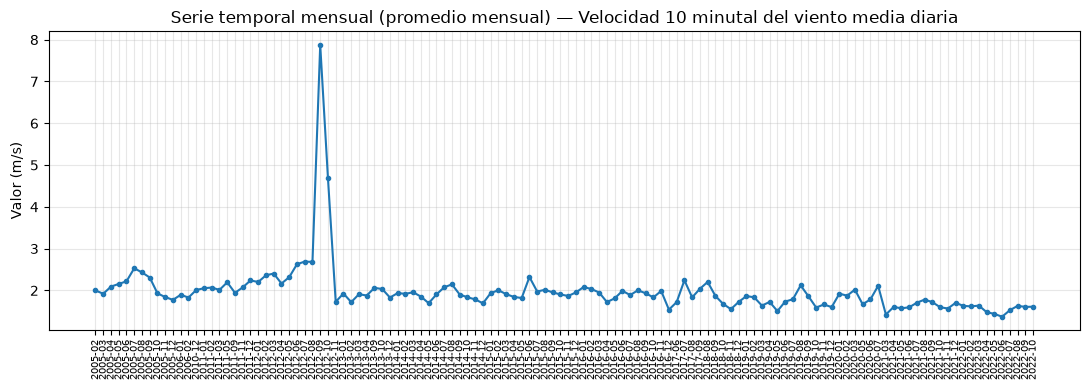

No se pudo generar el climograma: falta detectar temp_min o precipitacion en el mapeo.


In [ ]:

df = df_tibaitata.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month
df['Anio'] = df['Fecha'].dt.year
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# --- 1. Detección automática de parámetros clave por palabras clave ---
parametros_disponibles = df['Parametro'].dropna().unique()
print("Parámetros disponibles en el dataset:", list(parametros_disponibles))

def buscar_parametro(keywords):
    for p in parametros_disponibles:
        p_low = str(p).lower()
        if all(k in p_low for k in keywords):
            return p
    return None

# Si el auto-detect falla, sobreescribe aquí manualmente con el nombre exacto:
mapa_variables = {
    'temp_min': buscar_parametro(['temp', 'min']) or buscar_parametro(['tmin']),
    'precipitacion': buscar_parametro(['precip']),
    'humedad': buscar_parametro(['hum']) or buscar_parametro(['hr']),
}

print("\nMapeo detectado:")
for k, v in mapa_variables.items():
    print(f"  {k}: {v}")

# --- 2. Boxplot mensual para CADA parámetro disponible ---
for param in parametros_disponibles:
    sub = df[df['Parametro'] == param].dropna(subset=['Valor'])
    unidad = sub['Unidad'].dropna().iloc[0] if sub['Unidad'].notna().any() else ''

    datos_por_mes = [sub.loc[sub['Mes'] == m, 'Valor'].values for m in range(1, 13)]

    plt.figure(figsize=(9, 4))
    plt.boxplot(datos_por_mes, showmeans=True, tick_labels=meses_nombre)
    plt.title(f"Boxplot mensual — {param}")
    plt.ylabel(f"Valor ({unidad})" if unidad else "Valor")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 3. Histograma con umbrales para temp_min y precipitación ---
if mapa_variables['temp_min']:
    param = mapa_variables['temp_min']
    datos = df.loc[df['Parametro'] == param, 'Valor'].dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(datos, bins=30, color='#85B7EB', edgecolor='white')
    plt.axvline(0, color='#E24B4A', linestyle='--', linewidth=2, label='Umbral helada (0°C)')
    plt.title(f"Histograma — {param}")
    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

    n_heladas = (datos < 0).sum()
    print(f"Días con posible helada (T mín < 0°C): {n_heladas} de {len(datos)} ({n_heladas/len(datos)*100:.1f}%)")

if mapa_variables['precipitacion']:
    param = mapa_variables['precipitacion']
    datos = df.loc[df['Parametro'] == param, 'Valor'].dropna()
    p95 = datos.quantile(0.95)
    p99 = datos.quantile(0.99)

    plt.figure(figsize=(7, 4))
    plt.hist(datos, bins=30, color='#5DCAA5', edgecolor='white')
    plt.axvline(p95, color='#EDA100', linestyle='--', linewidth=2, label=f'P95 ({p95:.1f})')
    plt.axvline(p99, color='#E24B4A', linestyle='--', linewidth=2, label=f'P99 ({p99:.1f})')
    plt.title(f"Histograma — {param}")
    plt.xlabel(f"Precipitación ({df.loc[df['Parametro']==param, 'Unidad'].dropna().iloc[0] if df.loc[df['Parametro']==param,'Unidad'].notna().any() else ''})")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Días de lluvia extrema (> P95 = {p95:.1f}): {(datos > p95).sum()}")
    print(f"Días de lluvia extrema (> P99 = {p99:.1f}): {(datos > p99).sum()}")

# --- 4. Serie temporal mensual para CADA parámetro ---
for param in parametros_disponibles:
    sub = df[df['Parametro'] == param].dropna(subset=['Valor'])
    unidad = sub['Unidad'].dropna().iloc[0] if sub['Unidad'].notna().any() else ''

    if 'precip' in str(param).lower():
        serie_mensual = sub.groupby([sub['Fecha'].dt.to_period('M')])['Valor'].sum()
        etiqueta_agregacion = "suma mensual"
    else:
        serie_mensual = sub.groupby([sub['Fecha'].dt.to_period('M')])['Valor'].mean()
        etiqueta_agregacion = "promedio mensual"

    plt.figure(figsize=(11, 4))
    plt.plot(serie_mensual.index.astype(str), serie_mensual.values, marker='o', markersize=3, linewidth=1.5)
    plt.title(f"Serie temporal mensual ({etiqueta_agregacion}) — {param}")
    plt.ylabel(f"Valor ({unidad})" if unidad else "Valor")
    plt.xticks(rotation=90, fontsize=7)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Variables disponibles para cruzar: ['Humedad relativa del aire a 2 metros media diaria', 'Radiación solar global horaria VALIDADA', 'Temperatura máxima diaria', 'Temperatura mínima diaria', 'Velocidad 10 minutal del viento media diaria']


Parametro,Humedad relativa del aire a 2 metros media diaria,Radiación solar global horaria VALIDADA,Temperatura máxima diaria,Temperatura mínima diaria,Velocidad 10 minutal del viento media diaria
Fecha,,,,,
2005-02-02,89.531250,1696.5,19.8,4.6,1.644630
2005-02-03,83.958333,4480.5,20.2,5.6,1.964583
2005-02-04,89.236842,2363.3,18.6,6.8,2.149053
2005-02-05,80.562500,3137.0,20.4,9.0,2.557639
2005-02-06,89.500000,1992.7,18.8,10.8,1.965290



=== Matriz de correlación (Pearson) ===


Parametro,Humedad relativa del aire a 2 metros media diaria,Radiación solar global horaria VALIDADA,Temperatura máxima diaria,Temperatura mínima diaria,Velocidad 10 minutal del viento media diaria
Parametro,,,,,
Humedad relativa del aire a 2 metros media diaria,1.000,-0.430,-0.335,0.233,-0.254
Radiación solar global horaria VALIDADA,-0.430,1.000,0.563,-0.363,0.258
Temperatura máxima diaria,-0.335,0.563,1.000,-0.336,0.084
Temperatura mínima diaria,0.233,-0.363,-0.336,1.000,-0.005
Velocidad 10 minutal del viento media diaria,-0.254,0.258,0.084,-0.005,1.000


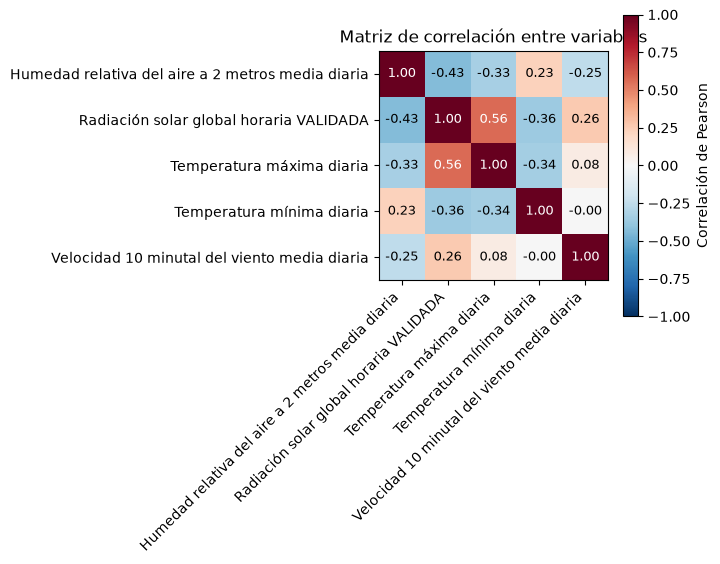

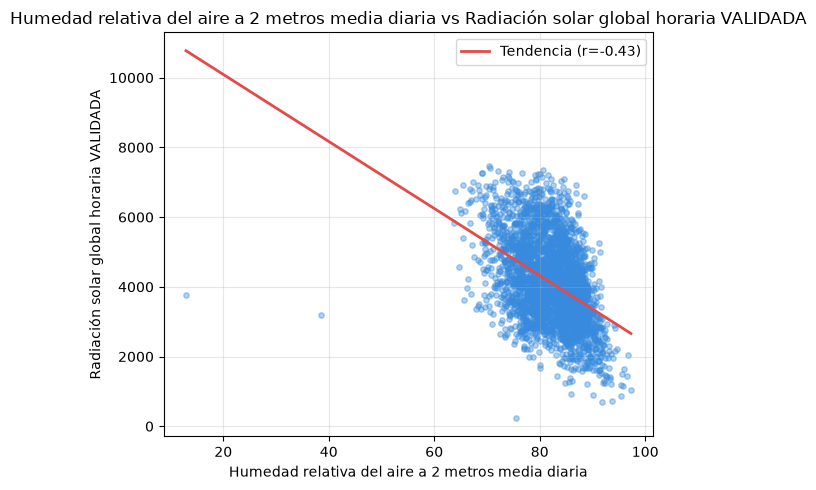

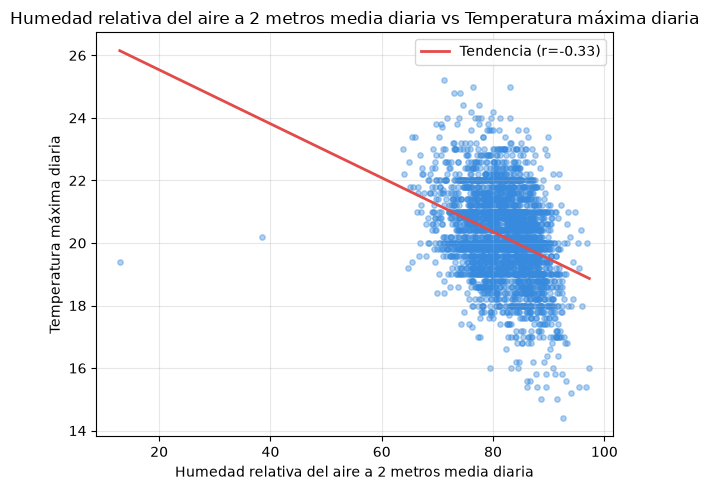

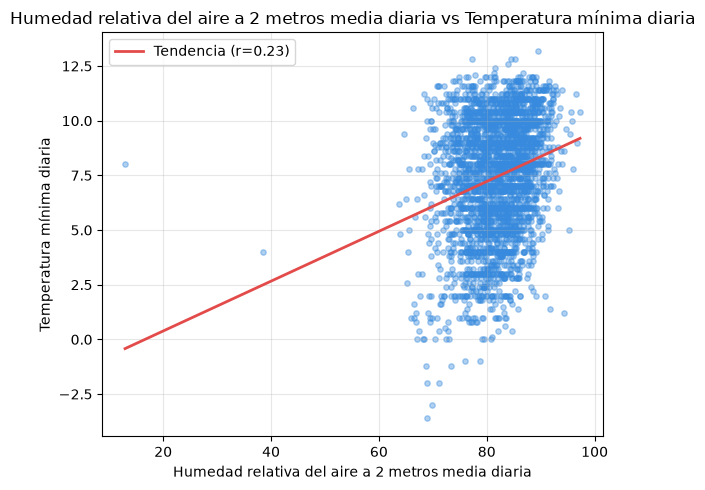

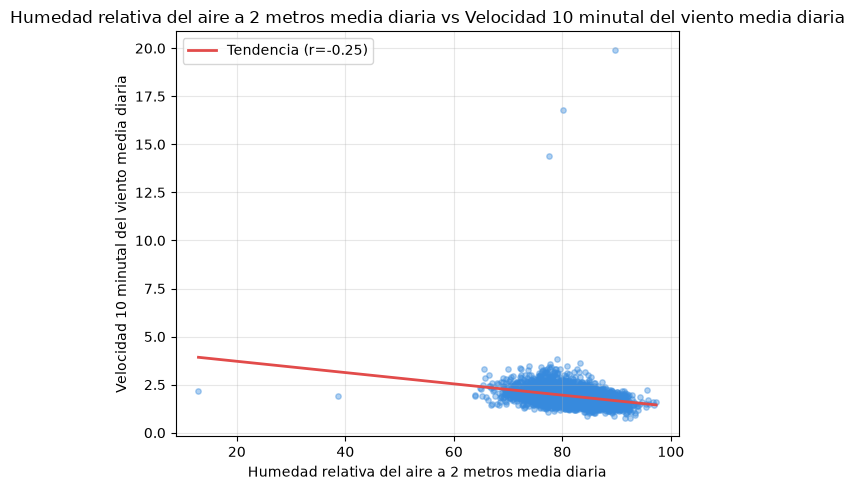

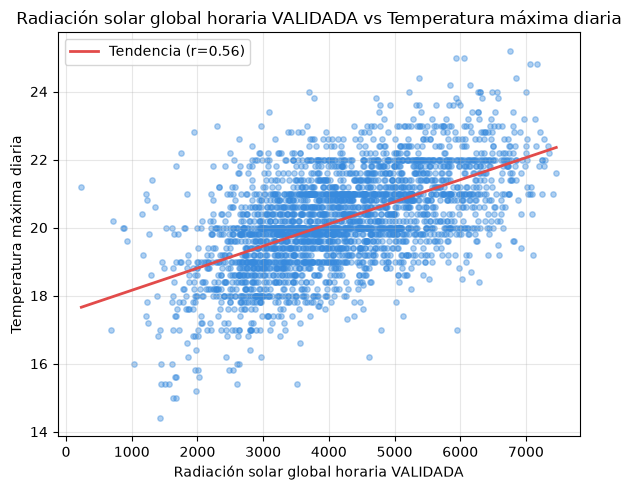

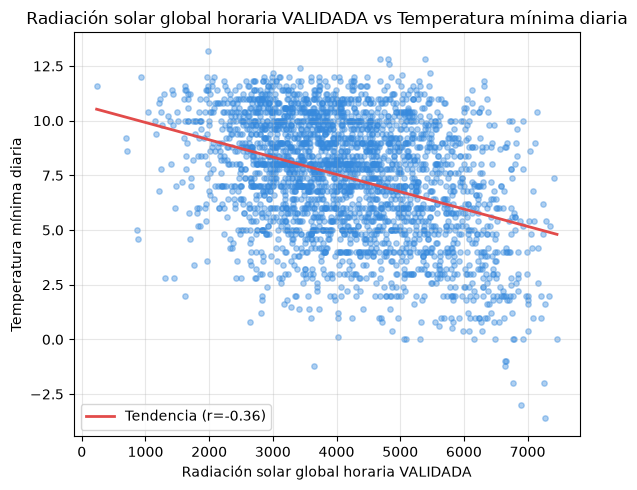

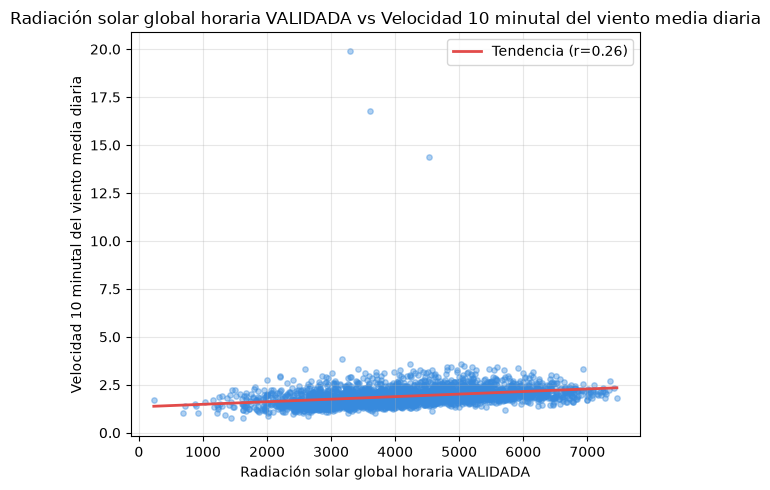

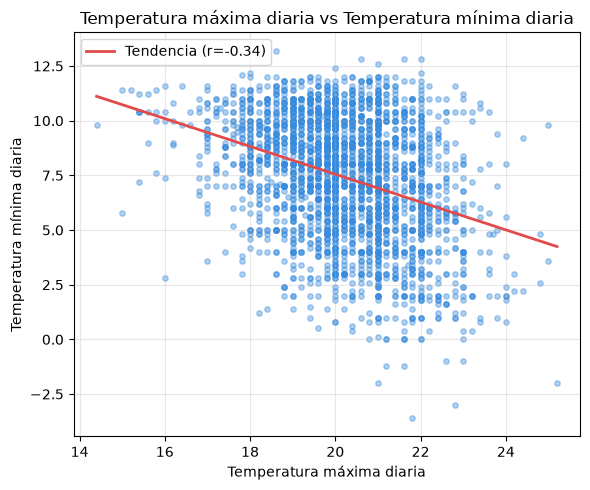

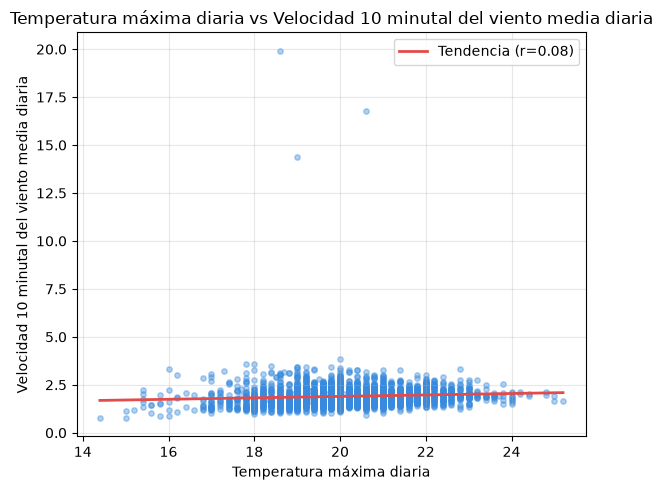

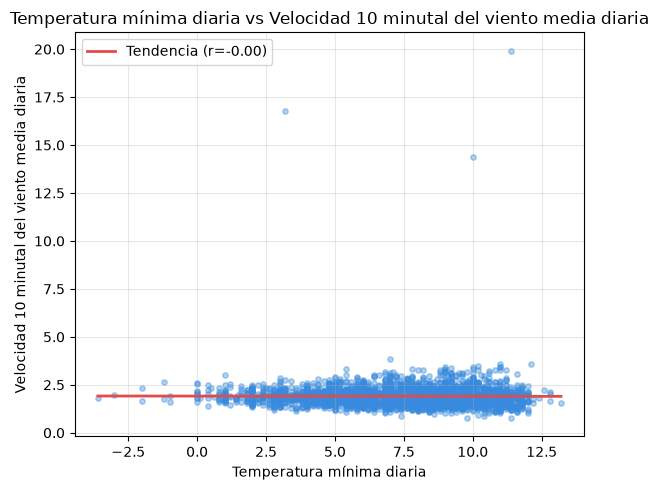

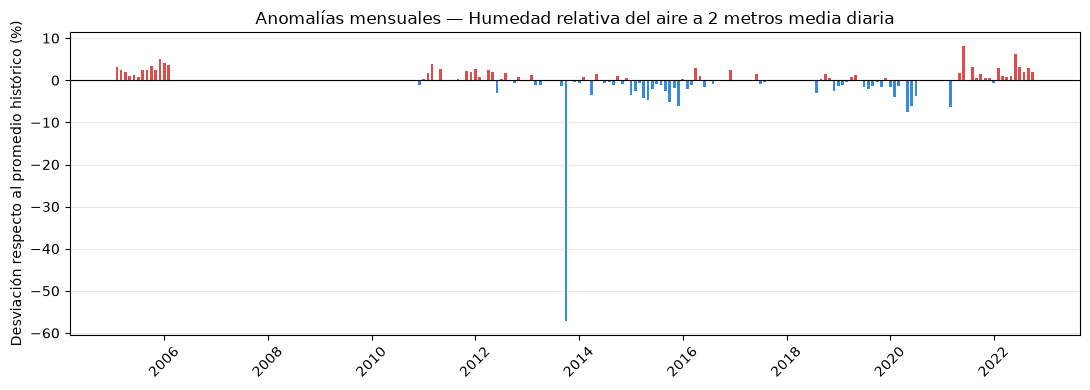

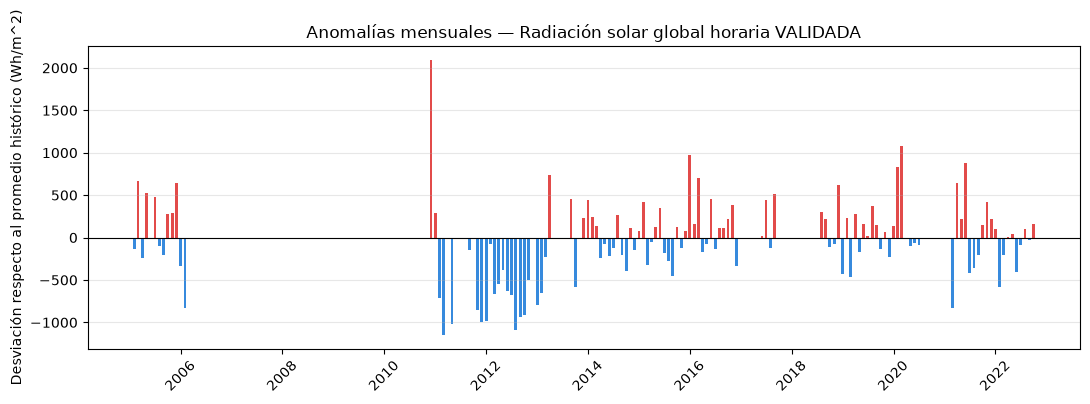

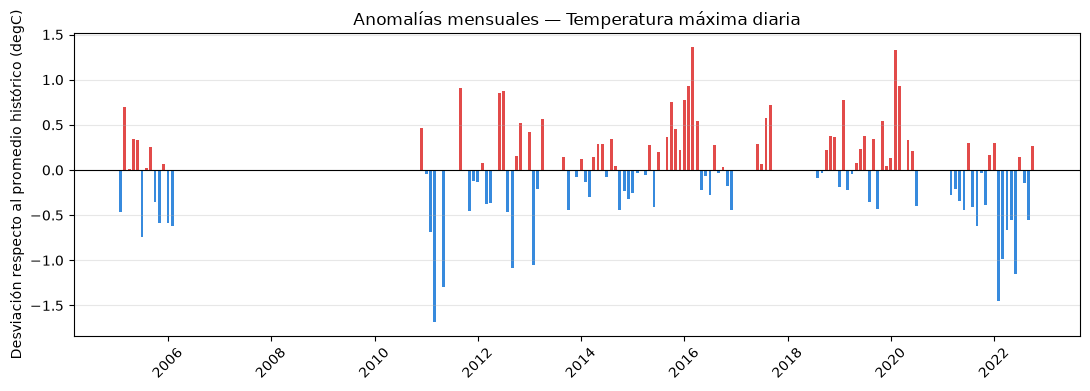

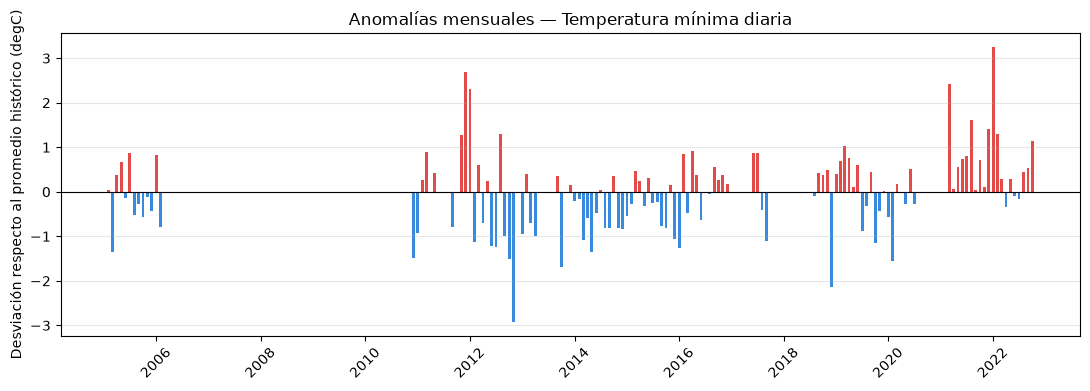

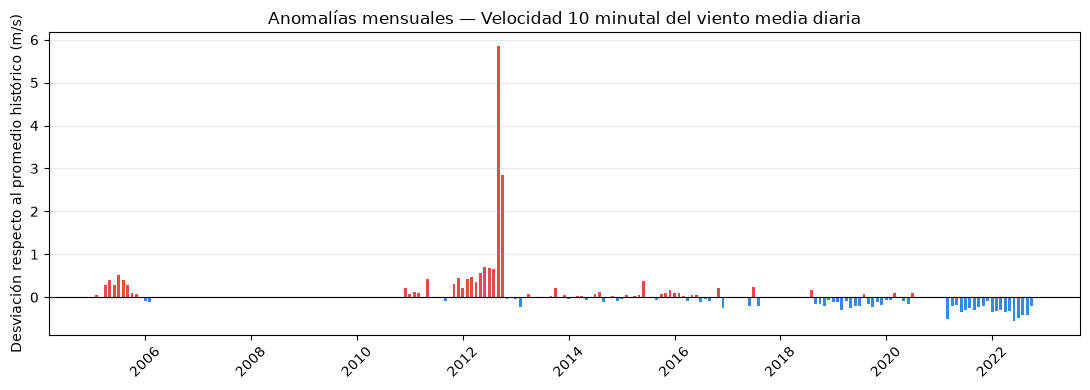

In [7]:
from itertools import combinations

df = df_tibaitata.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.month
df['Anio'] = df['Fecha'].dt.year

# --- Pivotear a formato ancho: una columna por Parametro ---
# Si hay más de un registro por Fecha+Parametro (ej. varias estaciones), se promedia
df_ancho = df.pivot_table(index='Fecha', columns='Parametro', values='Valor', aggfunc='mean')

print("Variables disponibles para cruzar:", list(df_ancho.columns))
display(df_ancho.head())

# ============================================================
# 1. MATRIZ DE CORRELACIÓN
# ============================================================
correlaciones = df_ancho.corr(method='pearson')

print("\n=== Matriz de correlación (Pearson) ===")
display(correlaciones.round(3))

plt.figure(figsize=(7, 6))
im = plt.imshow(correlaciones.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlación de Pearson')
plt.xticks(range(len(correlaciones.columns)), correlaciones.columns, rotation=45, ha='right')
plt.yticks(range(len(correlaciones.columns)), correlaciones.columns)

# Anotar los valores dentro de cada celda
for i in range(len(correlaciones.columns)):
    for j in range(len(correlaciones.columns)):
        valor = correlaciones.values[i, j]
        color_texto = 'white' if abs(valor) > 0.5 else 'black'
        plt.text(j, i, f"{valor:.2f}", ha='center', va='center', color=color_texto, fontsize=9)

plt.title("Matriz de correlación entre variables")
plt.tight_layout()
plt.show()

# ============================================================
# 2. DIAGRAMAS DE DISPERSIÓN (todos los pares de variables)
# ============================================================
variables = df_ancho.columns.tolist()
pares = list(combinations(variables, 2))

for var_x, var_y in pares:
    sub = df_ancho[[var_x, var_y]].dropna()
    if len(sub) < 2:
        continue

    corr_par = sub[var_x].corr(sub[var_y])

    plt.figure(figsize=(6, 5))
    plt.scatter(sub[var_x], sub[var_y], alpha=0.4, s=15, color='#378ADD')

    # Línea de tendencia
    coef = np.polyfit(sub[var_x], sub[var_y], 1)
    x_linea = np.linspace(sub[var_x].min(), sub[var_x].max(), 100)
    plt.plot(x_linea, np.polyval(coef, x_linea), color='#E24B4A', linewidth=2, label=f'Tendencia (r={corr_par:.2f})')

    plt.title(f"{var_x} vs {var_y}")
    plt.xlabel(var_x)
    plt.ylabel(var_y)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. GRÁFICO DE ANOMALÍAS (desviación respecto al promedio histórico del mismo mes)
# ============================================================
for param in variables:
    sub = df[df['Parametro'] == param].dropna(subset=['Valor'])
    if sub.empty:
        continue

    unidad = sub['Unidad'].dropna().iloc[0] if sub['Unidad'].notna().any() else ''

    # Promedio mensual real (por año-mes)
    mensual = sub.groupby([sub['Fecha'].dt.to_period('M')])['Valor'].mean()
    mensual.index = mensual.index.to_timestamp()

    # Promedio histórico "normal" por mes calendario (ene, feb, ... dic)
    promedio_historico_mes = sub.groupby(sub['Mes'])['Valor'].mean()

    # Anomalía = valor mensual real - promedio histórico de ese mes calendario
    anomalias = mensual - mensual.index.month.map(promedio_historico_mes)

    plt.figure(figsize=(11, 4))
    colores = ['#E24B4A' if v > 0 else '#378ADD' for v in anomalias.values]
    plt.bar(anomalias.index, anomalias.values, width=20, color=colores)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"Anomalías mensuales — {param}")
    plt.ylabel(f"Desviación respecto al promedio histórico ({unidad})" if unidad else "Desviación")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()